Projet analyse de donnée 
Romani Grégor
Rondeau Kélian

SUJET : PREDICTION DE PRIX DE AIRBNB
Le but va etre d'essayer de prédire le log du prix d'un airbnb en fonction de ses caractéristique

Dans un premier temps on importe et on vidualise notre base de donnée

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

import de la database

In [97]:
df_train = pd.read_csv("C:\\Users\\GREGOR\\Desktop\\ESILV\\analyse de donnee\\airbnb_train.csv")
df_test = pd.read_csv("C:\\Users\\GREGOR\\Desktop\\ESILV\\analyse de donnee\\airbnb_test.csv")


Visualisation de la data

In [100]:
df_train.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [102]:
df_train.columns

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

In [104]:
df_train.shape

(22234, 28)

In [106]:
df_train.isnull().values.any()

True

In [108]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22234 entries, 0 to 22233
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      22234 non-null  int64  
 1   log_price               22234 non-null  float64
 2   property_type           22234 non-null  object 
 3   room_type               22234 non-null  object 
 4   amenities               22234 non-null  object 
 5   accommodates            22234 non-null  int64  
 6   bathrooms               22183 non-null  float64
 7   bed_type                22234 non-null  object 
 8   cancellation_policy     22234 non-null  object 
 9   cleaning_fee            22234 non-null  bool   
 10  city                    22234 non-null  object 
 11  description             22234 non-null  object 
 12  first_review            17509 non-null  object 
 13  host_has_profile_pic    22178 non-null  object 
 14  host_identity_verified  22178 non-null

Voir si il y a des éléments sans valeurs

In [111]:
pd.isnull(df_train).sum()

id                           0
log_price                    0
property_type                0
room_type                    0
amenities                    0
accommodates                 0
bathrooms                   51
bed_type                     0
cancellation_policy          0
cleaning_fee                 0
city                         0
description                  0
first_review              4725
host_has_profile_pic        56
host_identity_verified      56
host_response_rate        5475
host_since                  56
instant_bookable             0
last_review               4716
latitude                     0
longitude                    0
name                         0
neighbourhood             2086
number_of_reviews            0
review_scores_rating      4978
zipcode                    303
bedrooms                    26
beds                        35
dtype: int64

Voir si il y a des doubles

In [114]:
print(df_train.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
22229    False
22230    False
22231    False
22232    False
22233    False
Length: 22234, dtype: bool


Netoyage des données et numerisation des colonnes

In [117]:
df_train = df_train.drop_duplicates()

In [119]:
print(df_train.duplicated().sum())

0


In [121]:
print(df_train.host_has_profile_pic.unique()) 
print(df_train.host_identity_verified.unique())
print(df_train.instant_bookable.unique())


['t' nan 'f']
['f' 't' nan]
['t' 'f']


Transformation des colonnes vrai faux en bool

In [124]:
df_train['host_has_profile_pic'] = df_train['host_has_profile_pic'].map({'t': True, 'f': False})
df_train['host_identity_verified'] = df_train['host_identity_verified'].map({'t': True, 'f': False})

df_train['host_response_rate'] = df_train['host_response_rate'].str.rstrip('%')
df_train['host_response_rate'] = df_train['host_response_rate'].astype(float)


df_train['instant_bookable'] = df_train['instant_bookable'].map({'t': True, 'f': False})

In [126]:
print(df_train.host_has_profile_pic.unique()) 
print(df_train.host_identity_verified.unique())
print(df_train.instant_bookable.unique())


[True nan False]
[False True nan]
[ True False]


Visualisation de la data par correlation avec la variable cible

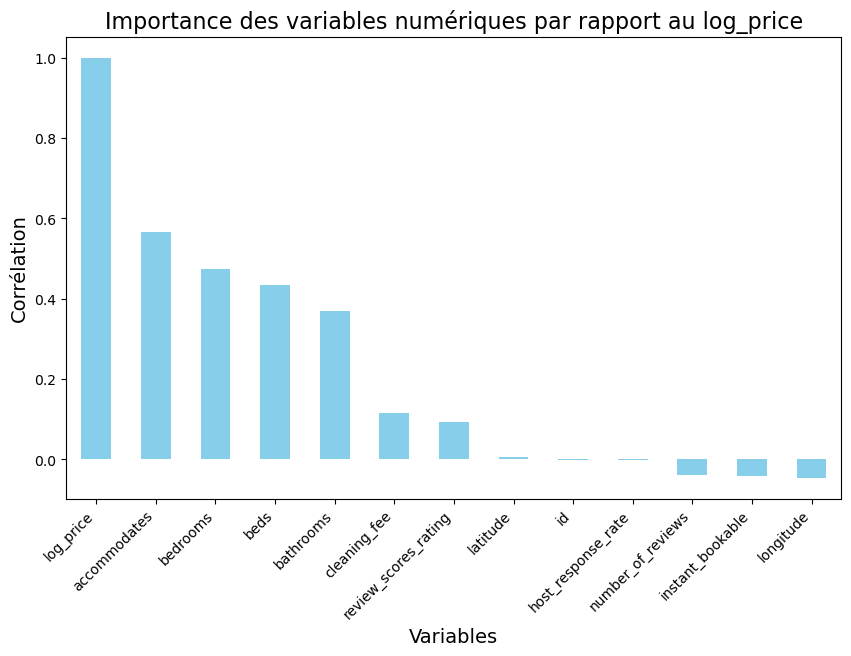

In [129]:
df_numeric = df_train.select_dtypes(include=['float64', 'int64', 'bool']) 
corr_log_price = df_numeric.corr().log_price.sort_values(ascending = False)


plt.figure(figsize=(10, 6))
corr_log_price.plot(kind='bar', color='skyblue')


plt.title('Importance des variables numériques par rapport au log_price', fontsize=16)
plt.xlabel('Variables', fontsize=14)
plt.ylabel('Corrélation', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()


Retirer les colonnes estimer innutiles

In [132]:
colonnes_inutiles = ['id','host_has_profile_pic', 'first_review','instant_bookable', 'last_review',
    'host_since', 'latitude', 'longitude','number_of_reviews','zipcode','amenities','description','name']

df_train.drop(columns=colonnes_inutiles, inplace=True)


In [134]:
print(df_train[['bathrooms', 'bedrooms', 'beds', 'review_scores_rating', 'host_response_rate', 'neighbourhood']].isnull().sum())

bathrooms                 51
bedrooms                  26
beds                      35
review_scores_rating    4978
host_response_rate      5475
neighbourhood           2086
dtype: int64


Gerrer les valeur nulle avec Pipeline

In [137]:
colonnes_num = ['bathrooms', 'bedrooms', 'beds', 'host_response_rate', 'review_scores_rating']
colonnes_str = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city', 'neighbourhood']
colonnes_bool = ['host_identity_verified', 'cleaning_fee']

x = df_train[colonnes_num + colonnes_str + colonnes_bool]
y = df_train['log_price']

#maintenant on va numeriser les colonnes colonnes_num et colonnes_str grace a pipeline dans sklearn

#SimpleImputer viens remplacer les val manquante par la valeur median de la colonne
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

str_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

bool_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))])


preprocessor = ColumnTransformer([('num', num_pipeline, colonnes_num),('str', str_pipeline, colonnes_str),
                                  ('bool', bool_pipeline, colonnes_bool)])


pipeline_rl = Pipeline([('preprocess', preprocessor),('model', LinearRegression())])


On prend 80% des donnée pour l'entrainement

In [146]:
n = x.shape[0]
n_train = int(0.8 * n)  # 80% pour l'entraînement

x_train = x[:n_train]
x_test = x[n_train:]
y_train = y[:n_train]
y_test = y[n_train:]

pipeline_rl.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bathrooms', 'bedrooms',
                                                   'beds', 'host_response_rate',
                                                   'review_scores_rating']),
                                                 ('str',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['property_type', 'room_type',
                                                   'bed_type',
                                                   'cancellation_policy',
                                                   'city', 'neighbourhood']),
                                                 ('bool',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['host_identity_verified',
                                                   'cleaning_fee'])])),
                ('model', LinearRegression())])

In [148]:
x_num_verif = num_pipeline.fit_transform(x_train[colonnes_num])
x_bool_verif = bool_pipeline.fit_transform(x_train[colonnes_num])
np.isnan(x_num_verif).sum()
np.isnan(x_bool_verif).sum()

0

Resultat de la regression lineaire

In [151]:
y_pred_rl = pipeline_rl.predict(x_test)
print("R² :", pipeline_rl.score(x_test, y_test))
print("MSE :", mean_squared_error(y_test, y_pred_rl, squared=False))


R² : 0.6292218113748652
MSE : 0.4390892988734618


C:\Users\GREGOR\anaconda3\3.12\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Visualisation RL

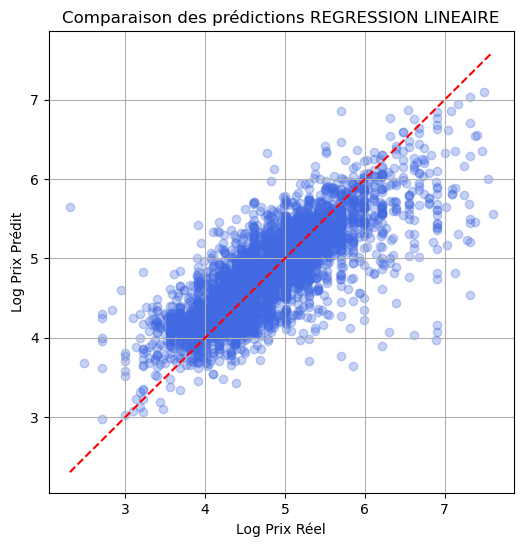

In [154]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rl, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Log Prix Réel")
plt.ylabel("Log Prix Prédit")
plt.title("Comparaison des prédictions REGRESSION LINEAIRE")
plt.grid()
plt.show()

On essaye d'avoir un meilleur resultat en passant par un SVR

In [157]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler


On standardise les données

In [160]:

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()


In [162]:

X_train = preprocessor.fit_transform(x_train)
X_test = preprocessor.transform(x_test)

Entraînement du modèle SVR

In [165]:

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train_scaled)

SVR()

Prediction

In [168]:

y_pred_svr_scaled = svr_model.predict(X_test)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1))
y_test_inverse = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))


Resultat SVR

In [171]:

print("R² :", r2_score(y_test_inverse, y_pred_svr))
print("MSE :", mean_squared_error(y_test_inverse, y_pred_svr, squared=False))


R² : 0.6459341765750117
MSE : 0.4290795018694122


C:\Users\GREGOR\anaconda3\3.12\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Graphique de la prédiction

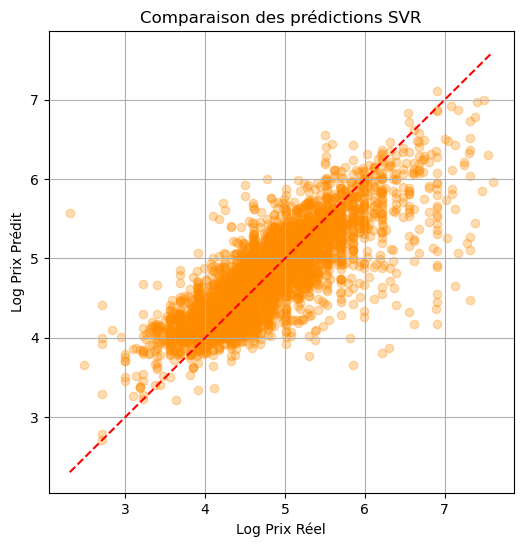

In [174]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_inverse, y_pred_svr, alpha=0.3, color='darkorange')
plt.plot([y_test_inverse.min(), y_test_inverse.max()], [y_test_inverse.min(), y_test_inverse.max()], 'r--')
plt.xlabel("Log Prix Réel")
plt.ylabel("Log Prix Prédit")
plt.title("Comparaison des prédictions SVR")
plt.grid()
plt.show()


Recherche des parametre pour optimiser notre SVR

In [177]:
from sklearn.svm import SVR

from sklearn.model_selection import GridSearchCV

In [179]:
parameters = {'C': [0.1,1, 10,100],'gamma': [0.01, 0.1],'kernel': ['rbf']}    
model = SVR()
grid = GridSearchCV(model, parameters, cv=3)
grid.fit(X_train, y_train_scaled)
print(grid.best_params_)
print(grid.best_estimator_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVR(C=10, gamma=0.01)


On remplace par les valeurs optimales trouver

In [181]:
svr_best = SVR(C=10, gamma=0.01, kernel='rbf')
X_train = preprocessor.fit_transform(x_train)
X_test = preprocessor.transform(x_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()


svr_best.fit(X_train, y_train_scaled)

y_pred_svr_scaled = svr_best.predict(X_test)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1))
y_test_inverse = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

print("R² :", r2_score(y_test_inverse, y_pred_svr))
print("MSE :", mean_squared_error(y_test_inverse, y_pred_svr, squared=False))


R² : 0.6536833711302872
MSE : 0.42435804150493334


C:\Users\GREGOR\anaconda3\3.12\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Graphique SVR avec les parametres optimiser

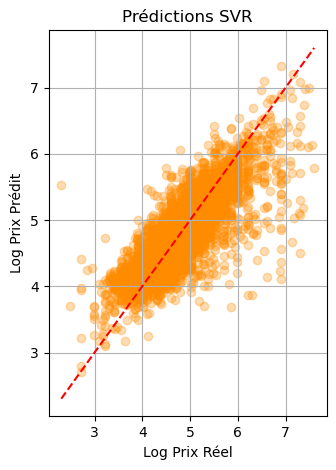

In [186]:
plt.subplot(1, 2, 2)
plt.scatter(y_test_inverse, y_pred_svr, alpha=0.3, color='darkorange')
plt.plot([y_test_inverse.min(), y_test_inverse.max()], [y_test_inverse.min(), y_test_inverse.max()], 'r--')
plt.xlabel("Log Prix Réel")
plt.ylabel("Log Prix Prédit")
plt.title("Prédictions SVR")
plt.grid()

plt.tight_layout()
plt.show()